### The Red Zone: Multimodal Injury Risk Prediction
**Author:** Clevin Alfred Vas  
**Module:** MSc Capstone Project, University of Galway  

**Project Objective:** Non-contact soft-tissue injuries tend to make a massive clinical and financial burden in elite sports. This project shows the development of an Early Warning System, that shows injury probability. It moves beyond traditional unimodal GPS tracking by integrating external workload, internal wellness, and biomechanical telemetry. 

Research Gaps Identified:
1. **EWMA (Exponentially Weighted Moving Averages):** To mathematically accurately model fatigue decay.
2. **SMOTE (Synthetic Minority Over-sampling Technique):** To maintain the statistical rarity of injury events.
3. **XGBoost:** A scalable ML system to map non-linear physiological interactions.
4. **SHAP (SHapley Additive exPlanations):** To solve the "black box" trust issue by providing clinical interpretation.

In [8]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import dice_ml
import warnings

# Notebook Configuration
warnings.filterwarnings('ignore')
print("All dependencies have been successfully loaded.")

All dependencies have been successfully loaded.


## Phase 1: Data Ingestion & Exploratory Data Analysis (EDA)
Before creatingg the predictive model, we try to understand the statistical distribution of the dataset. Here, we input the multimodal data and evaluate the distribution of the class imbalance (Injured vs. Healthy), which helps in understanding our need for SMOTE later in the pipeline.

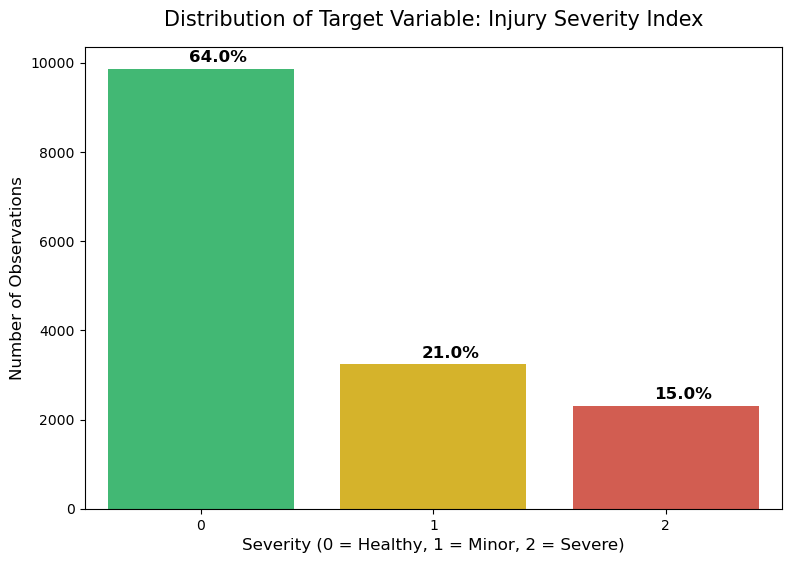

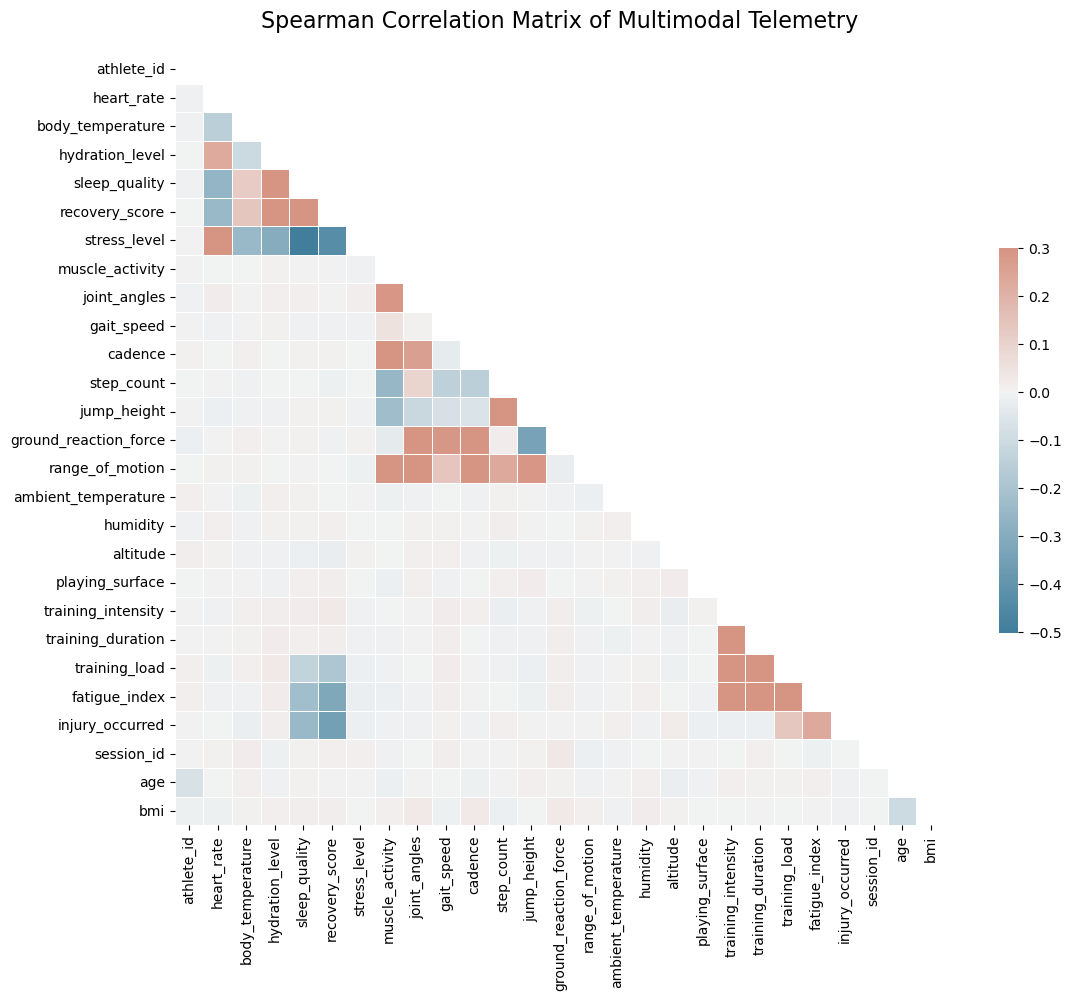

In [2]:
def perform_eda(filepath):
    df = pd.read_csv(filepath)
    
# Multiclass Class Imbalance Visualization
    plt.figure(figsize=(9, 6))
    ax = sns.countplot(data=df, x='injury_occurred', palette=['#2ECC71', '#F1C40F', '#E74C3C'])
    plt.title("Distribution of Target Variable: Injury Severity Index", fontsize=15, pad=15)
    plt.xlabel("Severity (0 = Healthy, 1 = Minor, 2 = Severe)", fontsize=12)
    plt.ylabel("Number of Observations", fontsize=12)
    
    # Show percentages
    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{100 * height / total:.1f}%'
            x = p.get_x() + p.get_width() / 2 - 0.05
            y = height + (total * 0.01)
            ax.annotate(percentage, (x, y), size=12, weight='bold')
    plt.show()
    
    # Multimodal Correlation Heatmap
    numeric_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(14, 10))
    corr = numeric_df.corr()
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title("Spearman Correlation Matrix of Multimodal Telemetry", fontsize=16, pad=20)
    plt.show()
    
    return df

raw_df = perform_eda('multimodal_sports_injury_dataset.csv')

## Phase 2: Time-Series Interpolation & EWMA
Missing values are a reality of wearable telemetry. Dropping them destroys the continuous timeline of human recovery. 
1. **Workloads:** Estimated via linear interpolation (connecting the dots).
2. **Subjective Wellness:** Forward-filled (assuming stress remains consistent if unlogged).
3. **ACWR:** Calculated using EWMA to mirror physiological decay, grouped strictly by `athlete_id`.

In [3]:
def engineer_features(df):
    print("Handling missing values using Time-Series Interpolation.")
    
    # Sorting to maintain exact chronological order for each athlete
    if 'session_id' in df.columns:
        df = df.sort_values(by=['athlete_id', 'session_id']).reset_index(drop=True)
        
    # Continuous Workload (Linear Interpolation)
    workload_cols = ['training_load', 'training_duration', 'training_intensity', 'step_count', 'gait_speed', 'jump_height']
    for col in workload_cols:
        if col in df.columns:
            df[col] = df.groupby('athlete_id')[col].transform(lambda x: x.interpolate(method='linear').fillna(method='bfill').fillna(0))
            
    # Subjective Wellness (Forward Fill)
    wellness_cols = ['sleep_quality', 'recovery_score', 'stress_level', 'fatigue_index', 'hydration_level']
    for col in wellness_cols:
        if col in df.columns:
            df[col] = df.groupby('athlete_id')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill').fillna(x.median()))

    # Biomechanical Data (Median Fallback)
    biomech_cols = ['cadence', 'joint_angles', 'ground_reaction_force', 'range_of_motion', 'muscle_activity']
    for col in biomech_cols:
        if col in df.columns:
            df[col] = df.groupby('athlete_id')[col].transform(lambda x: x.fillna(x.median()).fillna(0))
            

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col not in ['athlete_id', 'session_id', 'injury_occurred'] and df[col].isnull().sum() > 0:
            df[col] = df.groupby('athlete_id')[col].transform(lambda x: x.fillna(x.median()).fillna(0))

    # Calculating physiological fatigue decay
    df['acute_load_ewma'] = df.groupby('athlete_id')['training_load'].transform(lambda x: x.ewm(span=7, adjust=False).mean())
    df['chronic_load_ewma'] = df.groupby('athlete_id')['training_load'].transform(lambda x: x.ewm(span=28, adjust=False).mean())
    df['acwr_ewma'] = df['acute_load_ewma'] / (df['chronic_load_ewma'] + 1e-5)
    
    cols_to_drop = ['athlete_id', 
        'session_id', 
        'ambient_temperature', 
        'humidity', 
        'range_of_motion', 
        'ground_reaction_force', 
        'joint_angles', 
        'body_temperature']
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    

    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    if categorical_cols:
        df = pd.get_dummies(df, columns=categorical_cols)
        
    return df

processed_df = engineer_features(raw_df)

print(f"\nFeature engineering complete. Null values remaining: {processed_df.isnull().sum().sum()}")
display(processed_df.head())

Handling missing values using Time-Series Interpolation.

Feature engineering complete. Null values remaining: 0


,heart_rate,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,gait_speed,cadence,step_count,jump_height,...,bmi,acute_load_ewma,chronic_load_ewma,acwr_ewma,sport_type_Basketball,sport_type_Other,sport_type_Soccer,sport_type_Track,gender_Female,gender_Male
0,71.100491,76.481477,5.466370,77.899691,0.375825,10.000000,2.654327,50.000000,4961,0.453083,...,25.105748,548.417962,548.417962,1.000000,True,False,False,False,True,False
1,40.000000,72.363938,6.899090,74.845323,0.279165,310.293156,3.431107,89.032626,9006,0.265763,...,25.105748,545.824425,547.702504,0.996571,True,False,False,False,True,False
2,76.174609,100.000000,9.574152,83.538316,0.334061,158.659094,0.800000,73.088441,6775,0.850000,...,25.105748,571.314404,554.604699,1.030129,True,False,False,False,True,False
3,100.543724,86.172473,7.614297,79.966618,0.218766,107.079298,1.713869,50.000000,6579,0.489573,...,25.105748,512.624160,539.566681,0.950066,True,False,False,False,True,False
4,78.001235,83.195889,5.631979,56.945979,0.484086,164.347133,2.154233,71.288255,8157,0.466310,...,25.105748,508.487208,536.567348,0.947667,True,False,False,False,True,False


## Phase 3: Multiclass Cross-Validation & Tuning
To prevent the model from overfitting we generate synthetic data by using SMOTE.

Because we are predicting the Severity, XGBoost is mathematically designed to output a Multi-class probability (a continuous percentage array for Healthy, Minor, and Severe classes). The grid search is evaluated using the `roc_auc_ovr` metric to ensure optimal performance across all three classes.

In [4]:
print("Preparing data for Multiclass Tuning.")

X = processed_df.drop(columns=['injury_occurred'])
y = processed_df['injury_occurred']


split_idx = int(len(processed_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),                   
    ('smote', SMOTE(random_state=42)),              
    ('xgb', xgb.XGBClassifier(
        objective='multi:softprob', 
        eval_metric='mlogloss', 
        num_class=3,
        random_state=42
    ))
])

param_grid = {
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__n_estimators': [100, 150]
}

cv = StratifiedKFold(n_splits=3, shuffle=False)

print("Commencing GridSearchCV.")
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='roc_auc_ovr', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"\n Optimal Hyperparameters Found: {grid_search.best_params_}")

Preparing data for Multiclass Tuning.
Commencing GridSearchCV.
Fitting 3 folds for each of 8 candidates, totalling 24 fits

 Optimal Hyperparameters Found: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}


## Phase 4: Multiclass Evaluation
We evaluate the tuned multiclass model using a Confusion Matrix. This visualizes exactly where the model succeeds and fails for a particular instance, checking if the model mistakenly classifies a Severe tear as simply Healthy. The `ROC-AUC (OvR)` score confirms the model's overall discriminative ability.

Evaluating the model on unseen test data.

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.71      0.81      0.76      1974
   Minor (1)       0.20      0.03      0.05       653
  Severe (2)       0.47      0.75      0.58       457

    accuracy                           0.64      3084
   macro avg       0.46      0.53      0.46      3084
weighted avg       0.57      0.64      0.58      3084


ROC-AUC Score (OvR): 0.7000


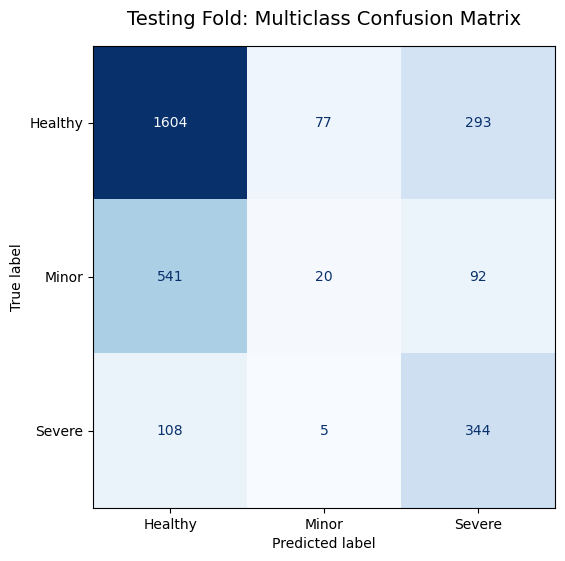

In [16]:
print("Evaluating the model on unseen test data.")

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Minor (1)', 'Severe (2)']))

roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print(f"\nROC-AUC Score (OvR): {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Minor', 'Severe'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("Testing Fold: Multiclass Confusion Matrix", fontsize=14, pad=15)
plt.grid(False)
plt.show()

## Phase 5: Deep Explainability with SHAP (Severe Injury Focus)
For a sports medicine practitioner, the most critical question is: Why is this exact player at risk of a Severe injury?, Because this is a multiclass model, SHAP generates a unique matrix of explanations for each different class.

Deconstructing the XGBoost decision trees for Severe injuries.


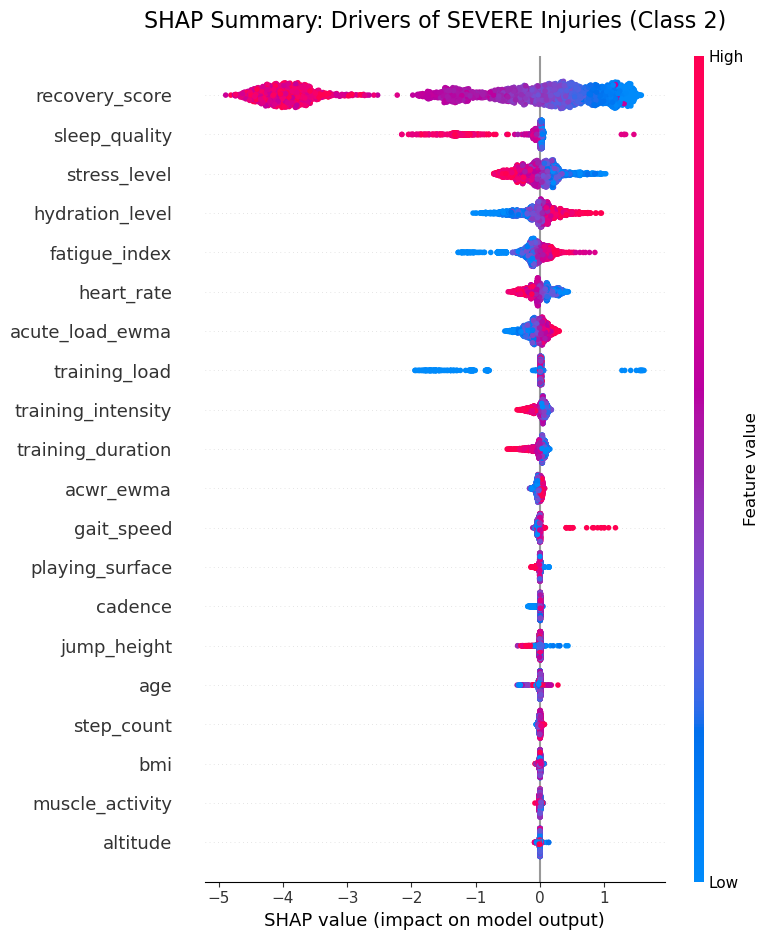


Generating SHAP Dependence Plot for Biomechanical Cadence.


<Figure size 800x600 with 0 Axes>

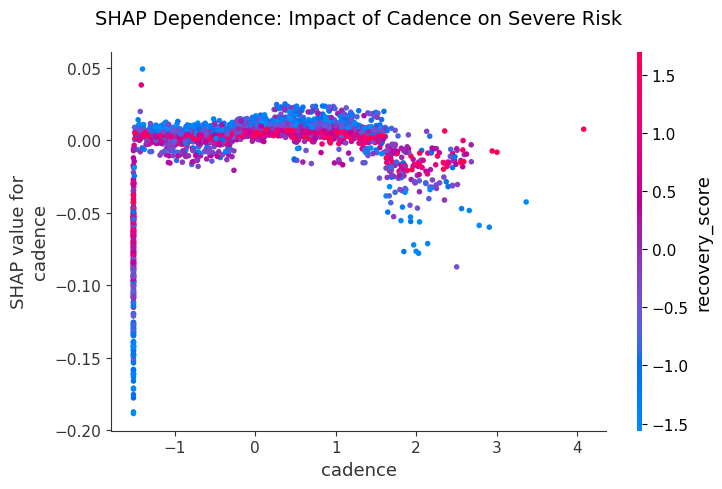


Multiclass Pipeline Execution Complete.


In [17]:
print("Deconstructing the XGBoost decision trees for Severe injuries.")

imputer = best_model.named_steps['imputer']
scaler = best_model.named_steps['scaler']
xgb_core = best_model.named_steps['xgb']

X_test_processed = scaler.transform(imputer.transform(X_test))

explainer = shap.TreeExplainer(xgb_core)
shap_values = explainer.shap_values(X_test_processed)

severe_shap_values = shap_values[2] 

# Global Summary Plot specifically for Severe Injuries
plt.figure(figsize=(10, 8))
shap.summary_plot(severe_shap_values, X_test_processed, feature_names=X_train.columns, show=False)
plt.title("SHAP Summary: Drivers of SEVERE Injuries (Class 2)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Plot 2: SHAP Dependence Plot (Checking Biomechanical breakdown)
if 'cadence' in X_train.columns:
    print("\nGenerating SHAP Dependence Plot for Biomechanical Cadence.")
    cadence_idx = X_train.columns.get_loc('cadence')
    
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        cadence_idx, 
        severe_shap_values, 
        X_test_processed, 
        feature_names=X_train.columns,
        show=False
    )
    plt.title("SHAP Dependence: Impact of Cadence on Severe Risk", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

print("\nMulticlass Pipeline Execution Complete.")

## Phase 6: Clinical Probability Calibration
To ensure the model's probability outputs are trustworthy for doctors, we calculate the Brier Score and will plot a Calibration Curve for Severe Injuries (Class 2).

Auditing model calibration for Major Injuries
Brier Score (only for severe injuries): 0.0911


<Figure size 800x600 with 0 Axes>

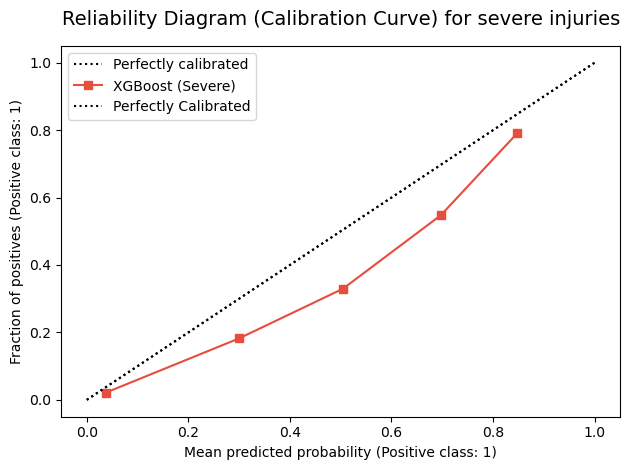

In [18]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

print("Auditing model calibration for Major Injuries")

y_test_severe = (y_test == 2).astype(int)
y_prob_severe = y_prob[:, 2] 

brier_score = brier_score_loss(y_test_severe, y_prob_severe)
print(f"Brier Score (only for severe injuries): {brier_score:.4f}")

plt.figure(figsize=(8, 6))
disp = CalibrationDisplay.from_predictions(
    y_test_severe, 
    y_prob_severe, 
    n_bins=5, 
    name="XGBoost (Severe)",
    color="#E74C3C"
)
plt.title("Reliability Diagram (Calibration Curve) for severe injuries", fontsize=14, pad=15)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")
plt.legend()
plt.tight_layout()
plt.show()

## Phase 7: Prescriptive AI (Counterfactual Explanations)
This phase introduces prescriptive analytics using Diverse Counterfactual Explanations (DiCE). By working alongside XGBoost model, we can generate individualized physiological interventions designed to shift an athlete from a 'Severe Injury Risk' (Class 2) back to a 'Healthy' baseline (Class 0).

In [11]:
train_dataset = X_train.copy()

for col in train_dataset.columns:
    if train_dataset[col].dtype == 'bool':
        train_dataset[col] = train_dataset[col].astype(int)

train_dataset['injury_occurred'] = y_train.astype(int)
continuous_features = train_dataset.columns.drop('injury_occurred').tolist()
d = dice_ml.Data(dataframe=train_dataset, continuous_features=continuous_features, outcome_name='injury_occurred')
m = dice_ml.Model(model=best_model, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")

# Finding a high risk player in the Test Set
severe_predictions = (y_pred == 2)
if severe_predictions.sum() > 0:
    at_risk_player = X_test[severe_predictions].iloc[[0]].copy()
    
    for col in at_risk_player.columns:
        if at_risk_player[col].dtype == 'bool':
            at_risk_player[col] = at_risk_player[col].astype(int)
            
    print("\nHigh Risk Player Identified.")
    
    # Restricting the AI to only change things the coach can actually control today
    actionable_features = ['training_load', 'sleep_quality', 'recovery_score', 'acute_load_ewma']
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dice_exp = exp.generate_counterfactuals(
            at_risk_player, 
            total_CFs=2, 
            desired_class=0,
            features_to_vary=actionable_features
        )
    
    print("\nInterventions:")
    dice_exp.visualize_as_dataframe(show_only_changes=True)
else:
    print("No severe injuries were predicted in this specific test batch!")


High Risk Player Identified.


100%|██████████| 1/1 [00:00<00:00,  8.14it/s]


Interventions:
Query instance (original outcome : 2)


,heart_rate,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,gait_speed,cadence,step_count,jump_height,...,acute_load_ewma,chronic_load_ewma,acwr_ewma,sport_type_Basketball,sport_type_Other,sport_type_Soccer,sport_type_Track,gender_Female,gender_Male,injury_occurred
0,54.157745,70.13813,5.232316,34.040268,0.200896,213.729675,1.663394,88.397438,13235,0.644059,...,907.348877,850.956543,1.066269,0,0,1,0,0,1,2



Diverse Counterfactual set (new outcome: 0)


,heart_rate,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,gait_speed,cadence,step_count,jump_height,...,acute_load_ewma,chronic_load_ewma,acwr_ewma,sport_type_Basketball,sport_type_Other,sport_type_Soccer,sport_type_Track,gender_Female,gender_Male,injury_occurred
0,-,-,-,58.9,-,-,-,-,-,-,...,1087.6,-,-,-,-,-,-,-,-,0.0
1,-,-,2.5,90.1,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0


## Phase 8: Streamlit Dashboard
Building a Streamlit Dashboard for the easier access of the medical authorities whi find it difficult to understand through the code. This is the final phase of the project.

In [13]:
import joblib
joblib.dump(best_model, 'clinical_xgboost_model.pkl')
print("Model exported.")

Model exported.
